In [233]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [196]:
# load the dataset

data = pd.read_csv(r"data\raw\set_e.csv")

In [197]:
# remove un-necessary columns
data = data.drop(columns=['record_id'])

- Task 1 — Maths & Adv Stats (5 Marks)
- Use only the 192 fit records after deduplication. For statistical calculations, use observed values rather than imputed values and report the sample size used.
    - M1 — Descriptive Statistics (1 Mark)
        - For load, report observed n, mean, median and sample standard deviation (ddof=1). Save a histogram with title and axis labels. Correct summary: 0.5; readable histogram: 0.5.

Observed n: 305
Mean of load column: 49.838819672131145
Median of load column: 50.05
Standard Deviation of load column: 9.955211372475441


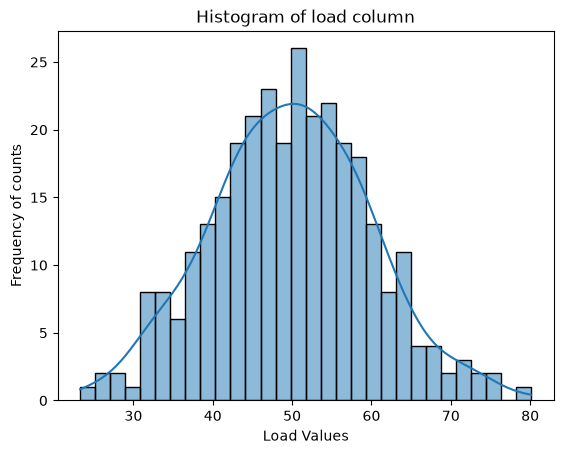

In [236]:
# ḷoad column's observed n, mean, median and standard deviation

print(f"Observed n: {len(data['load'])}")
print(f"Mean of load column: {np.mean(data['load'])}")
print(f"Median of load column: {np.median(data['load'])}")
print(f"Standard Deviation of load column: {np.std(data['load'], ddof=1)}")

# summary of the load column
# Total value of load column is 305
# Average of load column is 49.83
# Median of load column is 50.05
# Distance between each data point in load column is 9.95

sns.histplot(data['load'], bins=30, kde=True)
plt.title('Histogram of load column')
plt.xlabel('Load Values')
plt.ylabel('Frequency of counts')
plt.show()

# load column's histogram is normally distributed

- Task 2 - Data Preprocessing & Feature Engineering (5 Marks)

- F1 — Audit and Partition (2 Marks)
    - Report shape, exact duplicates, missing counts and target counts; verify 300 unique records after cleaning (1). Create the specified fit/validation/test partitions, save their IDs, and prove they are disjoint (1).


In [ ]:
# show shape of data
print(f"Shape of data: {data.shape}")

# show missing values
print(f"Count missing values: \n{data.isna().sum()}\n")

# count duplicate values
print(f"Count duplicate values: {data.duplicated().sum()}")

# drop duplicate values
data = data.drop_duplicates()

# check duplicate values removed or not
print(f"Verify duplicate values are removed or not: {data.shape}")

- F2 — Transform and Engineer (2 Marks)
    - Fit median imputation on numeric fit columns and one-hot encode group, handling unseen categories; transform validation/test without refitting (1). Create the specified engineered feature, then fit standard scaling on fit numeric features only; reuse it unchanged elsewhere (1). Keep group one-hot columns unscaled.


In [199]:
# create median imputer
median_imputer = sk.impute.SimpleImputer(strategy="median")

# create one hot encoder
one_hot_encoder = sk.preprocessing.OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# create new column named engineered_feature
data['engineered_feature'] = round(data['load'] * data['runtime'], 2)

# create standard scaler
std_scaler = sk.preprocessing.StandardScaler()

In [200]:
# combine different preprocessing techniques using column-transformer

median_scale_pipeline = sk.pipeline.Pipeline([
    ('impute', median_imputer),
    ('scale', std_scaler)
])

logistic_preprocessor = sk.compose.ColumnTransformer([
    ('impute_scale_pipeline', median_scale_pipeline, ['temperature', 'occupancy']),
    ('encode', one_hot_encoder, ['group']),
    ('scale', std_scaler, ['runtime', 'load', 'engineered_feature'])
])

- F3 — Leakage Evidence (1 Mark)
    - Print transformed shapes and feature names; verify finite numeric outputs. Explain why the target, record_id and test statistics are excluded from training. Save fitted preprocessing or provide executable code that recreates it.


In [201]:
# seperate the x and y features
x = data.drop(columns=['high_demand'])
y = data['high_demand']

# split the data into training and testing set
x_train, x_test, y_train, y_test = sk.model_selection.train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training set shape: {x_train.shape}")
print(f"Testing set shape: {x_test.shape}")

# """we don't include unique identifier and target column in training becuase, target column is the column from which we make a prediction and unique identifier column is useless column to make a prediction"""

Training set shape: (244, 6)
Testing set shape: (61, 6)


- Task 3 — Supervised Learning (5 Marks)
    - S1 — Baseline and Classifier (2 Marks)
        - Fit a majority-class DummyClassifier on the fit partition (0.5). Train LogisticRegression with max_iter=1000 on the transformed fit features (1). Document the target, predictors, model settings and fixed split IDs (0.5).


In [202]:
# build a pipeline

logistic_pipeline = sk.pipeline.Pipeline([
    ('preprocess', logistic_preprocessor),
    ('model', sk.linear_model.LogisticRegression(max_iter=1000))
])

In [203]:
# fit the model

logistic_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['temperature','occupancy','runtime','load','group','engineered_feature']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_scale_pipeline', ...), ('encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remaind

- S2 — Holdout Evaluation (2 Marks)
    - On the untouched test set, report baseline accuracy and classifier accuracy, precision, recall and F1 for positive class 1 (1). Save a labeled confusion matrix and per-record test predictions including record_id, true label, predicted label and class-1 probability (1). Use threshold 0.5 and document handling of undefined precision/recall.


Logistic Regression's accuracy score: 0.80
Logistic Regression's precision score: 0.88
Logistic Regression's recall score: 0.84
Logistic Regression's F1 score: 0.86


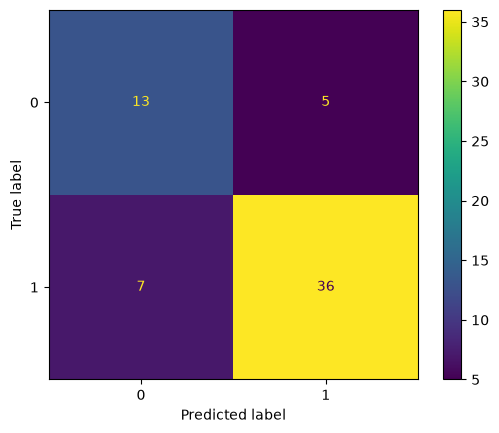

In [204]:
# predict the target feature
y_pred = logistic_pipeline.predict(x_test)

# evalute the model metrics
logistic_accuracy_score = sk.metrics.accuracy_score(y_test, y_pred)
logistic_precision_score = sk.metrics.precision_score(y_test, y_pred)
logistic_recall_score = sk.metrics.recall_score(y_test, y_pred)
logistic_f1_score = sk.metrics.f1_score(y_test, y_pred)

print(f"Logistic Regression's accuracy score: {logistic_accuracy_score:.2f}")
print(f"Logistic Regression's precision score: {logistic_precision_score:.2f}")
print(f"Logistic Regression's recall score: {logistic_recall_score:.2f}")
print(f"Logistic Regression's F1 score: {logistic_f1_score:.2f}")

# calculate the confusion matrix
cm = sk.metrics.confusion_matrix(y_test, y_pred)
sk.metrics.ConfusionMatrixDisplay(cm).plot()

- S3 — Interpretation (1 Mark)
    - Explain a false-positive versus false-negative consequence for this scenario. Use the test metrics and baseline to justify whether the classifier offers useful improvement. High accuracy is not a prerequisite for marks.

In [205]:
# "False positive means when its actual prediction is positive but, it make predicted as negative"
# "False positive means when its actual prediction is negative but, it make predicted as positive"

- Task 4 — Unsupervised Learning (5 Marks)
    - U1 — K-Means and Selection (3 Marks)
        - Use the transformed numeric fit predictors plus engineered_feature; exclude group one-hot columns, target and ID. Fit KMeans for k=2,3,4 with n_init=10 and random_state=42. Report inertia and silhouette score (1). Choose the highest-silhouette k; break ties with the smaller k and explain the choice (1).


In [206]:
# select features for clustering

X = data[['temperature', 'occupancy', 'runtime', 'load', 'high_demand', 'engineered_feature']]

In [207]:
# combine different preprocessing techniques using column-transformer

median_scale_pipeline = sk.pipeline.Pipeline([
    ('impute', median_imputer),
    ('scale', std_scaler)
])

clustering_preprocessor = sk.compose.ColumnTransformer([
    ('impute_scale_pipeline', median_scale_pipeline, ['temperature', 'occupancy']),
    ('scale', std_scaler, ['runtime', 'load', 'engineered_feature'])
])

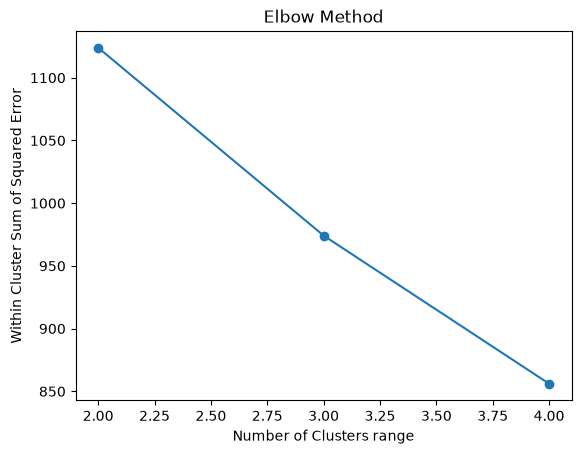

In [208]:
# find the best k for clustering

wcss = []

for k in [2, 3, 4]:
    pipeline = sk.pipeline.Pipeline([
        ('preprocess', clustering_preprocessor),
        ('clustering_algo', sk.cluster.KMeans(n_clusters = k, n_init = 10, random_state = 42))
    ])
    pipeline.fit(X)
    wcss.append(pipeline['clustering_algo'].inertia_)

plt.plot([2, 3, 4], wcss, marker = 'o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters range')
plt.ylabel('Within Cluster Sum of Squared Error')
plt.show()

In [209]:
# find the silhouette score of each cluster to determine the best score

silhouette_score = []

for k in [2, 3, 4]:
    pipeline = sk.pipeline.Pipeline([
        ('preprocess', clustering_preprocessor),
        ('clustering_algo', sk.cluster.KMeans(n_clusters = k, n_init = 10, random_state = 42))])
    labels = pipeline.fit_predict(X)
    score = sk.metrics.silhouette_score(pipeline['preprocess'].transform(X), labels)
    print(k, score)

2 0.22960817013872126
3 0.18264011603744287
4 0.1808519597995857


In [210]:
# build a final model with best k

clustering_pipeline = sk.pipeline.Pipeline([
    ('preporcess', clustering_preprocessor),
    ('clustering_algo', sk.cluster.KMeans(n_clusters = 3, n_init = 10, random_state = 42))
])
data['cluster'] = clustering_pipeline.fit_predict(X)

- U2 — Segment Interpretation (2 Mark)
    - Give each cluster a descriptive name based on its profile and propose one practical action. Explain why cluster IDs are arbitrary and do not represent target classes. Do not use test data or target labels to choose clusters.

In [211]:
# give the proper name to each cluster

data['cluster'] = data['cluster'].replace([0, 1, 2], ['low', 'medium', 'high'])

# """Since, clustering is unsupervised learning algorithm, which use unlabeled data and group similar data together, that's why it doesn't represent target classes."""

- Task 5 — Deep Learning up to ANN (5 Marks)
    - D1 — ANN Architecture and Compilation (2 Marks)
        - Implement a dense feed-forward ANN using TensorFlow/Keras or equivalent PyTorch: input width equals transformed feature count; hidden layers of 16 and 8 ReLU units; one sigmoid output. Display model summary and count trainable parameters (1). Use binary cross-entropy loss and Adam optimizer at learning rate 0.001; explain the output/loss choice (1).


In [212]:
# combine different preprocessing techniques using column-transformer

median_scale_pipeline = sk.pipeline.Pipeline([
    ('impute', median_imputer),
    ('scale', std_scaler)
])

encode_pipeline = sk.pipeline.Pipeline([
    ('encode', one_hot_encoder)
])

ann_preprocessor = sk.compose.ColumnTransformer([
    ('impute_scale_pipeline', median_scale_pipeline, ['temperature', 'occupancy']),
    ('encode_pipeline', encode_pipeline, ['group']),
    ('scale', std_scaler, ['runtime', 'load', 'engineered_feature'])
])

In [213]:
# fit and transform the training and testing set

preprocessod_x_train = ann_preprocessor.fit_transform(x_train)
preprocessod_x_test = ann_preprocessor.transform(x_test)

In [214]:
feature_names = ann_preprocessor.get_feature_names_out()

# Strip prefix before "__"
clean_names = [name.split('__', 1)[1] for name in feature_names]

x_train_df = pd.DataFrame(preprocessod_x_train, columns=clean_names, index=x_train.index)
x_test_df = pd.DataFrame(preprocessod_x_test, columns=clean_names, index=x_test.index)

In [215]:
# determine the input layer shape size

input_size = [x_train_df.shape[1]]

In [216]:
# set random seed
tf.random.set_seed(0)

# create ANN architecture

ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_size),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [217]:
# compile the model

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [218]:
# model summary

ann_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

- D2 — Training and Validation (2 Marks)
    - Train on the 192 fit records with batch size 16 for at most 50 epochs. Use the reserved 48 validation records and early stopping on validation loss with patience 5, restoring best weights. Record the actual epochs and random seed (1). Plot training and validation loss against epoch and discuss signs of underfitting or overfitting (1).

In [219]:
# create early-stopping callback

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

In [220]:
# fit the model

ann_model_history = ann_model.fit(x = x_train_df, y = y_train, batch_size = 16, epochs = 50, verbose = 1, callbacks = early_stopping, validation_split = 0.2)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6615 - loss: 0.6461 - val_accuracy: 0.6122 - val_loss: 0.6691
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7385 - loss: 0.6289 - val_accuracy: 0.6327 - val_loss: 0.6575
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7333 - loss: 0.6140 - val_accuracy: 0.6735 - val_loss: 0.6458
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7385 - loss: 0.5995 - val_accuracy: 0.6939 - val_loss: 0.6345
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7333 - loss: 0.5848 - val_accuracy: 0.6939 - val_loss: 0.6220
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7538 - loss: 0.5694 - val_accuracy: 0.7143 - val_loss: 0.6100
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7692 - loss: 0.5542 - val_accuracy: 0.7143 - val_loss: 0.5965
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7744 - loss: 0.5389 - val_accuracy: 0.7347 - val_loss

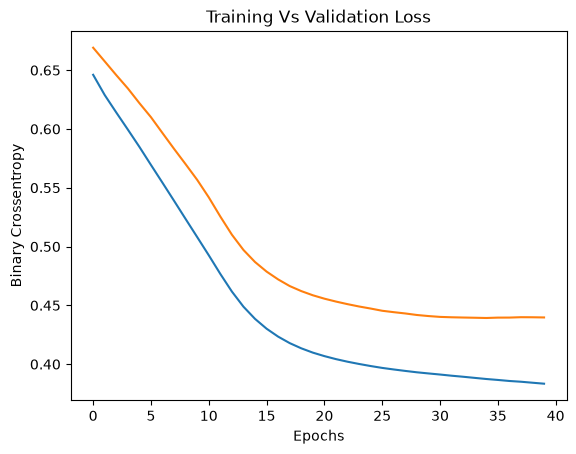

In [221]:
# plot the training and validation loss

plt.plot(ann_model_history.history['loss'], label = 'Training Loss')
plt.plot(ann_model_history.history['val_loss'], label = 'Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy')
plt.title('Training Vs Validation Loss')
plt.show()

- D3 — Comparison and Evidence (1 Mark)
    - Evaluate the restored ANN once on the same 60 test records using threshold 0.5. Report accuracy, precision, recall and F1, and compare F1 with logistic regression. Save ANN predictions and trained weights/model in models/. State a reasoned model preference; the ANN need not outperform logistic regression.


In [222]:
# predict the target feature
y_pred_ann = ann_model.predict(x_test_df)

# evaluate the model
y_pred_ann_labels = (y_pred_ann.ravel() >= 0.5).astype(int)
ann_accuracy_score = sk.metrics.accuracy_score(y_test, y_pred_ann_labels)
ann_precision_score = sk.metrics.precision_score(y_test, y_pred_ann_labels)
ann_recall_score = sk.metrics.recall_score(y_test, y_pred_ann_labels)
ann_f1_score = sk.metrics.f1_score(y_test, y_pred_ann_labels)

print(f"ANN accuracy score: {ann_accuracy_score:.2f}")
print(f"ANN precision score: {ann_precision_score:.2f}")
print(f"ANN recall score: {ann_recall_score:.2f}")
print(f"ANN F1 score: {ann_f1_score:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
ANN accuracy score: 0.84
ANN precision score: 0.90
ANN recall score: 0.86
ANN F1 score: 0.88


In [227]:
# compare ANN metrics with logistic regression's metrics

if ann_accuracy_score > logistic_accuracy_score:
    print("ANN's accuracy score is greater than logistic!")
    if ann_precision_score > logistic_precision_score:
        print("ANN's precision score is greater than logistic!")
        if ann_recall_score > logistic_recall_score:
            print("ANN's recall score is greater than logistic!")
            if ann_f1_score > logistic_f1_score:
                print("ANN's f1 score is greater than logistic!")
            else:
                print("Logistic's f1 score is greater than ANN!")
        else:
            print("Logistic's recall score is greater than ANN!")
    else:
        print("Logistic's precision score is greater than ANN!")
else:
    print("ANN's accuracy score is greater than logistic!")

ANN's accuracy score is greater than logistic!
ANN's precision score is greater than logistic!
ANN's recall score is greater than logistic!
ANN's f1 score is greater than logistic!
